# Imports
The necessary libraries are imported below.

In [1]:
import multiprocessing
multiprocessing.set_start_method('spawn', force=True)

In [2]:
import json
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import perf_counter
from scipy import stats
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix

# Keras with PyTorch backend
import os
os.environ["KERAS_BACKEND"] = "torch"
import torch
import keras
import keras_tuner
from keras import Sequential
from keras.metrics import F1Score
from keras.optimizers import Adam
from keras.layers import Conv1D, Dropout, LSTM, Dense
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [3]:
print(f"PyTorch sees CUDA: {torch.cuda.is_available()}")
print(f"Keras Backend: {keras.config.backend()}")

PyTorch sees CUDA: True
Keras Backend: torch


# Data Loading
First, raw data from a subject's experiment is loaded from the JSON file obtained from the Sensor Logger app. This is converted to a Pandas DataFrame using the following function.

In [4]:
def load_subject(filepath: str, subject_id: int) -> dict[str, pd.DataFrame]:
    """
    Load the raw data for a subject's experiment and return
    a dictionary with Pandas DataFrames.
    """
    with open(f"data/{filepath}", 'r') as f:
        records = json.load(f)

    column_names = set(key for r in records for key in r.keys())
    example_values = [example_value for example_value in records[0].values()]
    sensor_data = [r for r in records if r['sensor'] not in ('Metadata', 'Tags')]
    sensor_names = set(r['sensor'] for r in sensor_data)
    dfs: dict[str, pd.DataFrame] = {}

    print(f"Loaded experiment data from: {filepath}")
    print(f"Subject ID: {subject_id}")
    print(f"Column names: {column_names}")
    print(f"Example values: {example_values}\n")
    print(f"--- Sensors ---")
    
    for name in sensor_names:
        print(f"{name}:")

        # Create a DataFrame for this sensor
        rows = [r for r in sensor_data if r['sensor'] == name]
        df = pd.DataFrame(rows)

        # Set the DataFrame's index to the datetime
        df['time'] = pd.to_numeric(df['time'])
        df['time'] = pd.to_datetime(df['time'], unit='ns')
        df = df.sort_values('time').reset_index(drop=True)  # discard old index

        # The time column is used, so discard second_elapsed.
        # We create a DataFrame for each sensor and store the sensor name
        # in the dictionary key, so drop the sensor column.
        df = df.drop(columns=['sensor', 'seconds_elapsed'], errors='ignore')

        # Convert the values to numeric values, where
        # conversion failures yield NaN values.
        for col in df.columns:
            print(f"- {col}")
            if col != 'time':
                df[col] = pd.to_numeric(df[col], errors='coerce')  # error -> NaN
        print()

        # Add the subject ID as a column and store the DataFrame in the dictionary
        df['subject'] = subject_id
        dfs[name] = df

    print("DataFrame created successfully.")
    print("-" * 50)
    
    return dfs

subject1_dfs = load_subject(
    'subject_1_minutes_25_typing_writing_drawing-2026-06-06_18-30-20.json',
    subject_id=1
)

Loaded experiment data from: subject_1_minutes_25_typing_writing_drawing-2026-06-06_18-30-20.json
Subject ID: 1
Column names: {'recording epoch time', 'z', 'version', 'platform', 'altitude', 'bearing', 'qx', 'latitude', 'bpm', 'qw', 'qz', 'longitude', 'recording time', 'appVersion', 'relativeAltitude', 'device id', 'roll', 'yaw', 'speedAccuracy', 'device name', 'qy', 'standardisation', 'tag', 'pressure', 'y', 'sampleRateMs', 'sensor', 'sensors', 'horizontalAccuracy', 'x', 'pitch', 'time', 'recording timezone', 'seconds_elapsed', 'speed', 'bearingAccuracy', 'verticalAccuracy'}
Example values: ['HeartRate', '1780770621882000000', '1.208999755859375', '0']

--- Sensors ---
WatchGyroscope:
- time
- y
- z
- x

WatchAccelerometer:
- time
- y
- z
- x

HeartRate:
- time
- bpm

WatchGravity:
- time
- y
- z
- x

WatchBarometer:
- time
- relativeAltitude
- pressure

WatchOrientation:
- time
- qy
- qx
- yaw
- qw
- qz
- roll
- pitch

WatchLocation:
- time
- bearingAccuracy
- verticalAccuracy
- hori

The DataFrame for subject 1 (train) has been created. In the following cell, the loading function is used to create the DataFrame for subject 2 (test).

In [5]:
subject2_dfs = load_subject(
    'subject_2_minutes_25_typing_writing_drawing-2026-06-06_19-07-40.json',
    subject_id=2
)

Loaded experiment data from: subject_2_minutes_25_typing_writing_drawing-2026-06-06_19-07-40.json
Subject ID: 2
Column names: {'recording epoch time', 'z', 'version', 'platform', 'altitude', 'bearing', 'qx', 'latitude', 'bpm', 'qw', 'qz', 'longitude', 'recording time', 'appVersion', 'relativeAltitude', 'device id', 'roll', 'yaw', 'speedAccuracy', 'device name', 'qy', 'standardisation', 'tag', 'pressure', 'y', 'sampleRateMs', 'sensor', 'sensors', 'horizontalAccuracy', 'x', 'pitch', 'time', 'recording timezone', 'seconds_elapsed', 'speed', 'bearingAccuracy', 'verticalAccuracy'}
Example values: ['Metadata', '3', 'SM-L330', '1780772860505', '2026-06-06_19-07-40', 'Europe/Amsterdam', 'android', '1.58.1', 'SM-L330', 'heartrate|orientation|accelerometer|gravity|gyroscope|totalacceleration|location|barometer|magnetometer', '10|10|10|10|10|10|10|10|10', 'null']

--- Sensors ---
WatchGyroscope:
- time
- y
- z
- x

WatchAccelerometer:
- time
- y
- z
- x

HeartRate:
- time
- bpm

WatchGravity:
- t

For the validation set, subject 1 recorded themselves performing the writing, drawing, and typing activities for a total of ca. 7 minutes. This dataset is given Subject ID 3.

In [6]:
subject3_dfs = load_subject(
    'subject_1b_minutes_7_typing_writing_drawing-2026-06-18_06-30-22.json',
    subject_id=3
)

Loaded experiment data from: subject_1b_minutes_7_typing_writing_drawing-2026-06-18_06-30-22.json
Subject ID: 3
Column names: {'recording epoch time', 'z', 'version', 'platform', 'altitude', 'bearing', 'qx', 'latitude', 'bpm', 'qw', 'qz', 'longitude', 'recording time', 'appVersion', 'relativeAltitude', 'device id', 'roll', 'yaw', 'speedAccuracy', 'device name', 'qy', 'standardisation', 'pressure', 'tag', 'y', 'sampleRateMs', 'sensor', 'sensors', 'horizontalAccuracy', 'x', 'pitch', 'time', 'recording timezone', 'seconds_elapsed', 'speed', 'bearingAccuracy', 'verticalAccuracy'}
Example values: ['HeartRate', '1781764223563000000', '1.195', '57']

--- Sensors ---
WatchGyroscope:
- time
- y
- z
- x

WatchAccelerometer:
- time
- y
- z
- x

HeartRate:
- time
- bpm

WatchGravity:
- time
- y
- z
- x

WatchBarometer:
- time
- relativeAltitude
- pressure

WatchOrientation:
- time
- qy
- qx
- yaw
- qw
- qz
- roll
- pitch

WatchLocation:
- time
- bearingAccuracy
- verticalAccuracy
- horizontalAccur

Next, the data of each individual experiment is merged into a single DataFrame sensor-by-sensor.

In [7]:
# Take the union of the sensor names from both experiments
all_sensors = set(subject1_dfs.keys()) | set(subject2_dfs.keys() | set(subject3_dfs.keys()))

# Concatenate ('group-by-sensor'), stitching the data from subject 2 to the 
# back of the data from subject 1, and subject 3 (=1b) to the back of subject 2, 
# then sort by time (first recorded first)
sensor_dfs = {}
print(f"Sensor names:")
for sensor in all_sensors:
    print(f"- {sensor}")
    parts = []
    if sensor in subject1_dfs:
        parts.append(subject1_dfs[sensor])
    if sensor in subject2_dfs:
        parts.append(subject2_dfs[sensor])
    if sensor in subject3_dfs:
        parts.append(subject3_dfs[sensor])
    sensor_dfs[sensor] = pd.concat(parts, ignore_index=True).sort_values('time').reset_index(drop=True)

Sensor names:
- WatchGyroscope
- WatchAccelerometer
- HeartRate
- WatchGravity
- WatchBarometer
- WatchOrientation
- WatchLocation
- WatchTotalAcceleration
- WatchMagnetometer


The raw sensor data is recorded at 100 Hz (i.e., $\Delta t = 0.01 s$), but there could be jitter. The following cell gives the frequency distribution of sampling intervals for the accelerometer data.

In [8]:
acc_df = sensor_dfs['WatchAccelerometer']
intervals = acc_df['time'].diff().value_counts()
print(intervals)

time
0 days 00:00:00.010059       1026
0 days 00:00:00.010048        974
0 days 00:00:00.010058        913
0 days 00:00:00.010069        832
0 days 00:00:00.010070        807
                             ... 
0 days 00:00:00.010282400       1
0 days 00:00:00.009945500       1
0 days 00:00:00.010299700       1
0 days 00:00:00.009757700       1
0 days 00:00:00.009935300       1
Name: count, Length: 13172, dtype: int64


The sampling interval is not exactly 0.01 second (i.e., 00\:00\:00.01) between each observation. Next, the data is resampled to ensure alignment.

In [9]:
def resample_sensor(df: pd.DataFrame, sensor_name: str) -> pd.DataFrame:
    """
    Resample the data for a specific sensor 
    to ensure sample interval alignment.
    """
    results = []
    for subject_id, group in df.groupby('subject'):
        group = group.set_index('time').drop(columns='subject')
        group = group.resample('10ms').mean()  # ensure interval alignment
        group = group.ffill()  # forward fill NaN values
        
        # Rename the columns, e.g., WatchAccelerometer_x
        group.columns = [f'{sensor_name}_{col}' for col in group.columns]
        
        group['subject'] = subject_id
        results.append(group)
        
    return pd.concat(results)

resampled: dict[str, pd.DataFrame] = {sensor: resample_sensor(df, sensor) for sensor, df in sensor_dfs.items()}

The resampled data for each subject is merged into a single DataFrame separately. Then, the subject DataFrames are concatenated.

In [10]:
def merge_resampled(
    subject_ids: list[int], 
    df_dict: dict[str, pd.DataFrame]
) -> pd.DataFrame:
    """
    Merge the resampled df_dict into a single
    Pandas DataFrame for the specified subject_ids.
    """
    merged_subjects = []
    for subj_id in subject_ids:
        parts = []

        # Get the DataFrame (i.e., part) for this subject-sensor combination
        for sensor, df in df_dict.items():
            subj_df = df[df['subject'] == subj_id].drop(columns='subject')
            parts.append(subj_df)

        # Merge the parts into a single DataFrame for this subject,
        # using the time as index and sorting it lexicographically (outer)
        subj_merged = parts[0].join(parts[1:], how='outer')
        subj_merged['subject'] = subj_id  # reintroduce Subject ID
        merged_subjects.append(subj_merged)

    # Merge the subject DataFrames into a single DataFrame, adding the 
    # old 'time' index as a column, resetting the index to 0, 1, 2, etc. 
    merged_df = pd.concat(merged_subjects).reset_index()

    # Print dataset statistics
    print("--- Number of instances per subject ---")
    print(merged_df['subject'].value_counts())
    print(f"Shape: {merged_df.shape}\n")
    
    print("--- Frequency distribution of sampling rate ---")
    time_diffs = merged_df['time'].diff()
    print(time_diffs.value_counts())
    weird_delta = time_diffs[time_diffs != '0 days 00:00:00.010000']
    
    print("\n--- Weird time delta ---")
    print(weird_delta)

    print("\n--- NaN value counts ---")
    print(merged_df.isnull().sum())

    return merged_df

merged = merge_resampled([1, 2, 3], resampled)

--- Number of instances per subject ---
subject
2    151726
1    151027
3     42339
Name: count, dtype: int64
Shape: (345092, 36)

--- Frequency distribution of sampling rate ---
time
0 days 00:00:00.010000     345089
0 days 00:12:09.470000          1
11 days 10:57:24.700000         1
Name: count, dtype: int64

--- Weird time delta ---
0                            NaT
151027    0 days 00:12:09.470000
302753   11 days 10:57:24.700000
Name: time, dtype: timedelta64[ns]

--- NaN value counts ---
time                                  0
WatchGyroscope_y                      6
WatchGyroscope_z                      6
WatchGyroscope_x                      6
WatchAccelerometer_y                  0
WatchAccelerometer_z                  0
WatchAccelerometer_x                  0
HeartRate_bpm                       567
WatchGravity_y                        9
WatchGravity_z                        9
WatchGravity_x                        9
WatchBarometer_relativeAltitude      43
WatchBarometer_pressur

Now, the $\Delta t$ is consistent. The only 'weird' time delta is found at the start time point of the dataset for both the second and third experiments. Indeed, the second subject did not start recording data immediately after the first subject had finished their experiment. Thus, the different time delta is not an error, but expected.

# Data Exploration

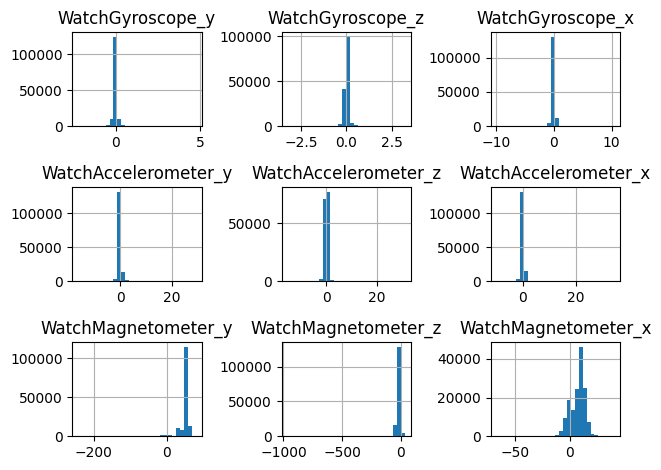

In [11]:
motion_cols = [col for col in merged.columns if any(
    s in col for s in ['WatchAccelerometer', 'WatchGyroscope', 'WatchMagnetometer']
)]

subj1_pre_clean_df = merged[merged['subject'] == 1]
subj1_pre_clean_df[motion_cols].hist(bins=30)
plt.tight_layout()
plt.show()

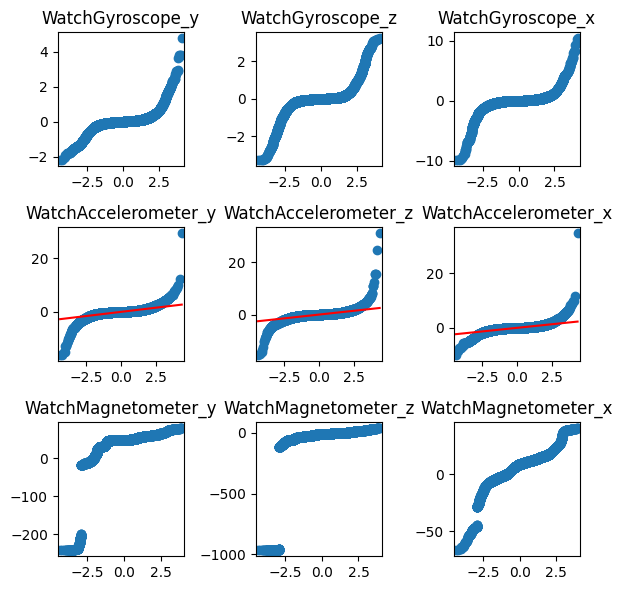

In [12]:
from statsmodels.graphics.gofplots import qqplot
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(6,6))
ax = ax.flatten()
for i, col in enumerate(motion_cols):
    s = subj1_pre_clean_df[col]
    qqplot(s, line='s', ax=ax[i])
    ax[i].set_title(col)
    ax[i].set_xlabel("")
    ax[i].set_ylabel("")
plt.tight_layout()
plt.show()

In [13]:
for col in motion_cols:
    s = subj1_pre_clean_df[col]
    stat, p = stats.normaltest(s, nan_policy='omit')
    print(f'Statistic={stat:.3f}, p={p:e}')

Statistic=63506.186, p=0.000000e+00
Statistic=61919.899, p=0.000000e+00
Statistic=92995.623, p=0.000000e+00
Statistic=56539.279, p=0.000000e+00
Statistic=84901.885, p=0.000000e+00
Statistic=113084.762, p=0.000000e+00
Statistic=235714.712, p=0.000000e+00
Statistic=326541.253, p=0.000000e+00
Statistic=47574.532, p=0.000000e+00


Each D'Agostino's $K^2$ test result gives an extremely small p-value of approximately zero, much smaller than the significance level $\alpha=0.05$. Therefore, for each data series, the null hypothesis $H_0$ that the sample is Gaussian, is rejected. Thus, it is unlikely that the data of any of the motion columns are Gaussian.

# Data Cleaning
In this section, noise is removed from the data and missing values are handled.

In [14]:
def chauvenet_count(series: pd.Series, c=2, visualize=False):
    """
    Chauvenet's criterion: Reject a measurement when the
    probability of observing it is less than 1 / (c*N).

    The data is assumed to follow the standard normal
    distribution.
    
    Given a Pandas Series and the parameter c, a positive 
    constant between 1-10 (default 2) specifying the degree 
    of certainty for outlier identification, return the 
    number of outliers detected.
    """
    # Determine the length of the series N, discarding 
    # NaN values, and set the Chauvenet's criterion
    series = series.copy()
    mask = series.notna()
    vals = series[mask]
    N = len(vals)
    if N == 0:
        return series
    criterion = 1.0 / (c * N)

    # Get the original mean and standard deviation
    mu, sigma = vals.mean(), vals.std()
    
    # Get the probability for each data point using the
    # Normal Cumulative Distribution Function.
    prob = stats.norm.cdf(vals, loc=mu, scale=sigma)

    # An outlier is a point where the following holds:
    # 1-P < 1/cN   OR
    # P < 1/cN
    outlier_mask = (1.0 - prob < criterion) | (prob < criterion)
    outlier_series = vals[outlier_mask]
    result = len(outlier_series)

    if visualize and result > 0:
        signed_z_scores = (vals - mu) / sigma
        print(f"The {series.name} column has {result} outliers after dropping NaN values.")
        print(f"Chauvenet's criterion: 1 / ({c} * {N}) = {criterion:.2e}")
        print(f"Outliers are those data points where (1-P) < {criterion:.2e} or P < {criterion:.2e}\n")
        
        print("Data points on the Standard Normal Distribution:\n")
        z_critical = stats.norm.ppf(1 - criterion)
        draw_min = min(signed_z_scores.min(), -z_critical) - 1
        draw_max = max(signed_z_scores.max(), z_critical) + 1
        x_axis = np.linspace(draw_min, draw_max, 1000)
        y_pdf = stats.norm.pdf(x_axis, loc=0, scale=1)
        data_pdf = stats.norm.pdf(signed_z_scores, loc=0, scale=1)
        xlabel, ylabel = 'z', 'Probability Density'
        bound_label = f"Rejection Boundary (Z = ±{z_critical:.2f})"
        obj = {xlabel: x_axis, ylabel: y_pdf}
        plt.figure()
        plt.plot(xlabel, ylabel, data=obj)
        plt.scatter(signed_z_scores, data_pdf, s=4)
        plt.axvline(z_critical, color='red', label=bound_label, linestyle=':', linewidth=1)
        plt.axvline(-z_critical, color='red', linestyle=':', linewidth=1)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.legend(loc="upper right")
        plt.show()
        
    return result

The above function can be used to count the number of outliers using Chauvenet's criterion. Below, this outlier detection technique is visualized for an example series.

The WatchGyroscope_y column has 3723 outliers after dropping NaN values.
Chauvenet's criterion: 1 / (2 * 345086) = 1.45e-06
Outliers are those data points where (1-P) < 1.45e-06 or P < 1.45e-06

Data points on the Standard Normal Distribution:



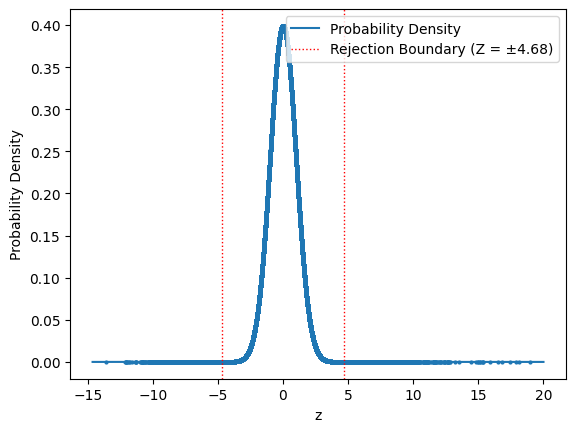

In [15]:
sensor_cols = [col for col in merged.columns if col not in ('time', 'subject')]

# Compute the number of outliers and visualize an example
for col in sensor_cols:
    s = merged[col]
    
    n_chauvenet = chauvenet_count(s, visualize=True)
    
    if n_chauvenet > 0:
        break

Next, a DataFrame is constructed for summary statistics. The outlier detection yields the following result on the dataset.

In [16]:
rows = []
for col in sensor_cols:
    s = merged[col]
    total = len(s)
    n_nan = int(s.isna().sum())
    n_zero = int((s == 0).sum())

    # Compute the number of outliers
    n_chauvenet = chauvenet_count(s)
    
    rows.append({
        'column': col,
        'total': total,
        'missing': n_nan,
        'missing_%': round(100 * n_nan / total, 2),
        'zeros': n_zero,
        'chauvenet_outliers_(c=2)': n_chauvenet,
        'min': round(s.min(), 3) if s.notna().any() else None,
        'max': round(s.max(), 3) if s.notna().any() else None,
    })

summary = pd.DataFrame(rows).set_index('column')
summary

,total,missing,missing_%,zeros,chauvenet_outliers_(c=2),min,max
column,,,,,,,
WatchGyroscope_y,345092,6,0.00,2819,3723,-3.429,4.754
WatchGyroscope_z,345092,6,0.00,3884,3575,-5.497,4.932
WatchGyroscope_x,345092,6,0.00,1855,2896,-11.591,11.955
WatchAccelerometer_y,345092,0,0.00,1919,2274,-23.159,29.317
WatchAccelerometer_z,345092,0,0.00,2441,2326,-15.385,30.955
WatchAccelerometer_x,345092,0,0.00,4198,2778,-11.044,34.448
HeartRate_bpm,345092,567,0.16,7847,7847,0.000,123.000
WatchGravity_y,345092,9,0.00,0,34,-9.806,7.995
WatchGravity_z,345092,9,0.00,0,378,-8.323,9.807


## Domain knowledge outlier removal for HeartRate
A heart rate of 0 bpm is physiologically impossible and indicates a sensor dropout. We replace these with NaN for imputation in Step 3.

In [17]:
merged['HeartRate_bpm'] = merged['HeartRate_bpm'].replace(0, np.nan)

## Chauvenet's criterion for motion sensors
Accelerometer, Gyroscope, Gravity, TotalAcceleration, and Magnetometer produce continuous normally distributed measurements, making Chauvenet appropriate. We use $c=2$ per subject to avoid mixing subject distributions. Flagged values are replaced with NaN for imputation. Orientation is excluded as it is a bounded signal in $[-\pi, \pi]$ and
does not satisfy the normality assumption.

In [18]:
def chauvenet(series: pd.Series, c=2):
    """
    Chauvenet's criterion: Reject a measurement when the
    probability of observing it is less than 1 / (c*N).

    The data is assumed to follow the standard normal
    distribution.
    
    Given a Pandas Series and the parameter c, a positive 
    constant between 1-10 (default 2) specifying the degree 
    of certainty for outlier identification, replace the 
    values of the outliers by NaN values in the Series.
    """
    # Determine the length of the series N, discarding 
    # NaN values, and set the Chauvenet's criterion
    series = series.copy()
    mask = series.notna()
    vals = series[mask]
    N = len(vals)
    if N == 0:
        return series
    criterion = 1.0 / (c * N)

    # Get the original mean and standard deviation
    mu, sigma = vals.mean(), vals.std()
    
    # Get the probability for each data point using the
    # Normal Cumulative Distribution Function.
    prob = stats.norm.cdf(vals, loc=mu, scale=sigma)

    # An outlier is a point where the following holds:
    # 1-P < 1/cN   OR
    # P < 1/cN
    outlier_mask = (1.0 - prob < criterion) | (prob < criterion)

    # Replace the values of the outliers by NaN values
    series[mask] = series[mask].where(~outlier_mask, np.nan)

    return series

# Select the normally distributed columns from the dataset
chauvenet_cols = [col for col in merged.columns if any(
    s in col for s in ['WatchAccelerometer', 'WatchGyroscope', 'WatchGravity',
                       'WatchTotalAcceleration', 'WatchMagnetometer']
)]

# Replace the values of the outliers by NaN values
for col in chauvenet_cols:
    for subj in [1, 2, 3]:
        mask = merged['subject'] == subj
        merged.loc[mask, col] = chauvenet(merged.loc[mask, col])

## Linear interpolation for all remaining missing values
Interpolation is preferred over mean imputation for temporal data as it respects the trend between surrounding measurements. Applied per subject to avoid interpolating across recording boundaries. The `ffill` and `bfill` methods handle edges where interpolation cannot extrapolate.

In [19]:
# Interpolate per subject for NaN values
for col in [c for c in merged.columns if c not in ('time', 'subject')]:
    for subj in [1, 2, 3]:
        mask = merged['subject'] == subj
        merged.loc[mask, col] = (
            merged.loc[mask, col]
            .interpolate(method='linear')
            .ffill()
            .bfill()
        )

print("Missing values remaining after cleaning:")
missing = merged.isnull().sum()
print(missing[missing > 0] if missing.any() else "None")

Missing values remaining after cleaning:
None


In case there are missing values remaining, the following cell shows the missing values per subject.

In [20]:
for subj in [1, 2, 3]:
    missing = merged[merged['subject'] == subj].isnull().sum()
    missing = missing[missing > 0]
    print(f"Subject {subj}: {'None' if missing.empty else missing}")

Subject 1: None
Subject 2: None
Subject 3: None


## Post-cleaning summary
There should be no NaN values remaining. As a final check, the following cell shows a summary.

In [21]:
sensor_cols = [col for col in merged.columns if col not in ('time', 'subject')]

rows = []
for col in sensor_cols:
    s = merged[col]
    n_nan = int(s.isna().sum())
    rows.append({
        'column': col,
        'missing': n_nan,
        'missing_%': round(100 * n_nan / len(s), 2),
    })

post_summary = pd.DataFrame(rows).set_index('column')
print("Post-cleaning missing values:")
print(post_summary[post_summary['missing'] > 0] if post_summary['missing'].any() else "None")

Post-cleaning missing values:
None


## Heart rate cleaning visualization
The plots below show the effect of data cleaning on the heart rate data of subject 1.

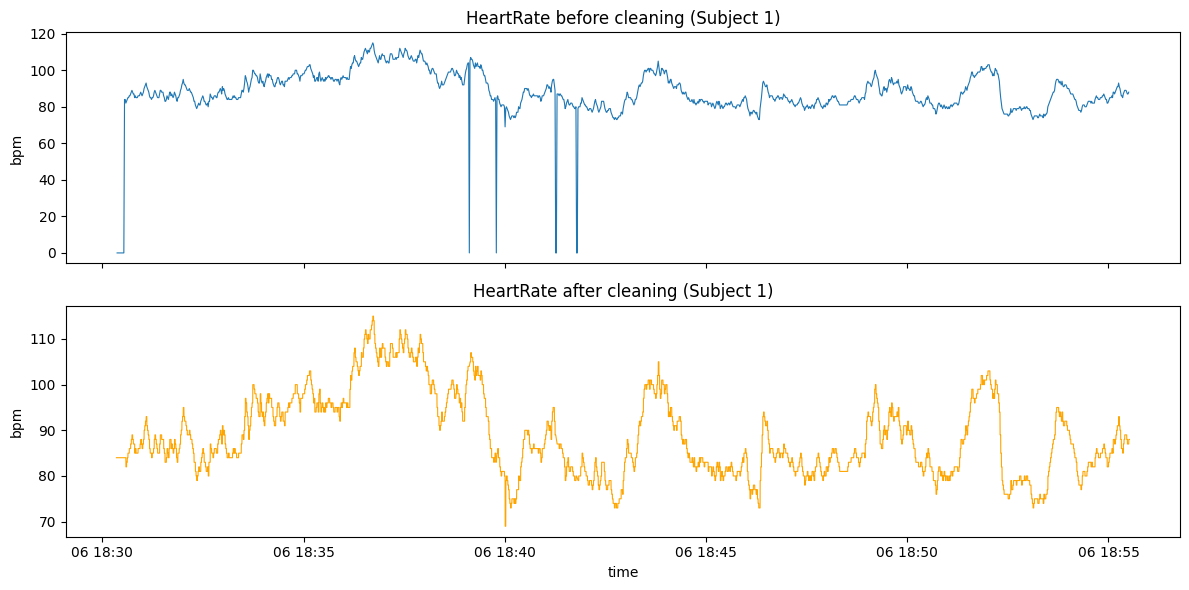

In [22]:
# Get the raw dataset of subject 1
with open('data\subject_1_minutes_25_typing_writing_drawing-2026-06-06_18-30-20.json') as f:
    records = json.load(f)
hr_raw = pd.DataFrame([r for r in records if r['sensor'] == 'HeartRate'])
hr_raw['time'] = pd.to_datetime(pd.to_numeric(hr_raw['time']), unit='ns')
hr_raw['bpm'] = pd.to_numeric(hr_raw['bpm'])
hr_raw = hr_raw.set_index('time').sort_index()

# Get the cleaned dataset for subject 1
subj1 = merged[merged['subject'] == 1].set_index('time')

# Create the figure
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Create the plot of the raw dateset for subject 1
axes[0].plot(hr_raw.index, hr_raw['bpm'], linewidth=0.8)
axes[0].set_title('HeartRate before cleaning (Subject 1)')
axes[0].set_ylabel('bpm')

# Create the plot of the cleaned dateset for subject 1
axes[1].plot(subj1.index, subj1['HeartRate_bpm'], linewidth=0.8, color='orange')
axes[1].set_title('HeartRate after cleaning (Subject 1)')
axes[1].set_ylabel('bpm')
axes[1].set_xlabel('time')

# Show and save the figure
plt.tight_layout()
plt.savefig('figures/heartrate_before_after.png', dpi=150)
plt.show()

# Feature Engineering
In this section, features are extracted and the usefulness of those features is analyzed.

## Assign activity labels from recorded timestamps

In [23]:
activity_bounds = {
    1: [
        ('typing',  120, 507),
        ('writing', 533, 1268),
        ('drawing', 1290, 1485),
    ],
    2: [
        ('typing',  21,  464),
        ('writing', 468, 1095),
        ('drawing', 1111, 1309),
    ],
    3: [
        ('typing',  10,  88),
        ('writing', 100, 262),
        ('drawing', 285, 404),
    ],
}

merged['label'] = None

for subj, bounds in activity_bounds.items():
    mask = merged['subject'] == subj
    t0 = merged.loc[mask, 'time'].min()
    elapsed = (merged.loc[mask, 'time'] - t0).dt.total_seconds()
    for activity, t_start, t_end in bounds:
        in_window = mask & (elapsed >= t_start) & (elapsed <= t_end)
        merged.loc[in_window, 'label'] = activity

print(merged['label'].value_counts(dropna=False))

label
writing    152403
typing      90803
drawing     51203
None        50683
Name: count, dtype: int64


## Select accelerometer, gyroscope, and magnetometer columns

In [24]:
df = merged[['time', 'subject', 'label'] + motion_cols].copy()

print(f"Retained {len(motion_cols)} motion sensor columns:")
print(motion_cols)

Retained 9 motion sensor columns:
['WatchGyroscope_y', 'WatchGyroscope_z', 'WatchGyroscope_x', 'WatchAccelerometer_y', 'WatchAccelerometer_z', 'WatchAccelerometer_x', 'WatchMagnetometer_y', 'WatchMagnetometer_z', 'WatchMagnetometer_x']


## Feature extraction over sliding windows

In [25]:
def extract_features(df, motion_cols, window, step, fs=100):
    freqs = np.fft.rfftfreq(window, d=1 / fs)
    feature_rows = []

    for subj in [1, 2, 3]:
        subj_df = df[df['subject'] == subj].reset_index(drop=True)
        vals   = subj_df[motion_cols].values
        labels = subj_df['label'].values
        times  = subj_df['time'].values
        n      = len(subj_df)

        for t in range(window - 1, n, step):
            label = labels[t]
            if label is None:
                continue

            win = vals[t - window + 1 : t + 1]

            row = {'time': times[t], 'subject': subj, 'label': label}

            for j, col in enumerate(motion_cols):
                w = win[:, j]

                # time domain
                row[f'{col}_mean'] = w.mean()
                row[f'{col}_std']  = w.std()
                row[f'{col}_min']  = w.min()
                row[f'{col}_max']  = w.max()

                # frequency domain (exclude 0 Hz / DC component)
                amps  = np.abs(np.fft.rfft(w))
                amps_osc  = amps[1:]
                freqs_osc = freqs[1:]
                total_amp = amps_osc.sum()

                row[f'{col}_max_freq']  = freqs_osc[np.argmax(amps_osc)]
                row[f'{col}_freq_wavg'] = float((amps_osc * freqs_osc).sum() / total_amp) if total_amp > 0 else 0.0

                power = (amps ** 2) / window
                total = power.sum()
                if total > 0:
                    p = power / total
                    p = p[p > 0]
                    row[f'{col}_pse'] = float(-np.sum(p * np.log(p)))
                else:
                    row[f'{col}_pse'] = 0.0

            feature_rows.append(row)

    return pd.DataFrame(feature_rows).reset_index(drop=True)


WINDOW  = 200                          
OVERLAP = 0.5                          
STEP    = int(WINDOW * (1 - OVERLAP))

features = extract_features(df, motion_cols, WINDOW, STEP)

print(features['label'].value_counts())
print(features.shape)
print(features.describe())

label
writing    1524
typing      908
drawing     512
Name: count, dtype: int64
(2944, 66)
                                time      subject  WatchGyroscope_y_mean  \
count                           2944  2944.000000            2944.000000   
mean   2026-06-08 04:36:56.167133440     1.674592              -0.016143   
min       2026-06-06 18:32:21.870000     1.000000              -0.403684   
25%    2026-06-06 18:45:03.620000256     1.000000              -0.031339   
50%       2026-06-06 19:10:37.100000     2.000000              -0.015974   
75%    2026-06-06 19:22:56.849999872     2.000000               0.005412   
max       2026-06-18 06:37:06.550000     3.000000               0.202221   
std                              NaN     0.680853               0.038921   

       WatchGyroscope_y_std  WatchGyroscope_y_min  WatchGyroscope_y_max  \
count           2944.000000           2944.000000           2944.000000   
mean               0.110492             -0.316639              0.298089   

## Compare window sizes

   window_s  instances  n_windows  mean_eta2   mean_F
0       1.0        100       5888      0.078  305.204
1       2.0        200       2944      0.087  176.657
2       5.0        500       1175      0.106   93.106

Most separable window: 5s (500 instances), mean eta2 = 0.106


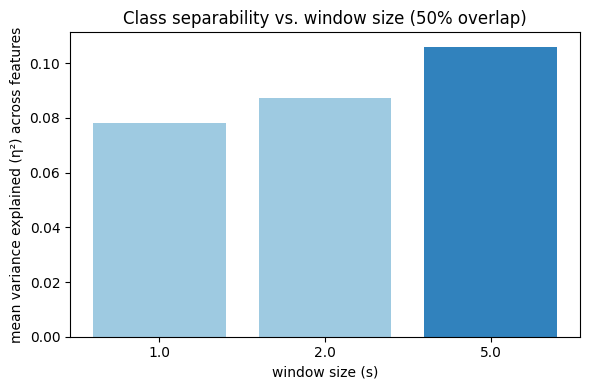

In [26]:
window_sizes = [100, 200, 500] 
k = 3                            

results = []
for win in window_sizes:
    step  = int(win * (1 - OVERLAP))   # same overlap as the main run
    feats = extract_features(df, motion_cols, win, step)
    X = feats.drop(columns=['time', 'subject', 'label'])
    y = feats['label']
    N = len(feats)

    F, _ = f_classif(X, y)

    eta2 = (F * (k - 1)) / (F * (k - 1) + (N - k))

    results.append({
        'window_s':  win / 100,
        'instances': win,
        'n_windows': N,
        'mean_eta2': np.nanmean(eta2),
        'mean_F':    np.nanmean(F),
    })

window_comparison = pd.DataFrame(results)
print(window_comparison.round(3))

best_row = window_comparison.loc[window_comparison['mean_eta2'].idxmax()]
print(f"\nMost separable window: {best_row['window_s']:.0f}s "
      f"({best_row['instances']:.0f} instances), mean eta2 = {best_row['mean_eta2']:.3f}")

best = window_comparison['mean_eta2'].max()
colors = ['#3182bd' if v == best else '#9ecae1' for v in window_comparison['mean_eta2']]

plt.figure(figsize=(6, 4))
plt.bar(window_comparison['window_s'].astype(str), window_comparison['mean_eta2'], color=colors)
plt.xlabel('window size (s)')
plt.ylabel('mean variance explained (η²) across features')
plt.title(f'Class separability vs. window size ({OVERLAP:.0%} overlap)')
plt.tight_layout()
plt.savefig('figures/window_size_comparison.png', dpi=150)
plt.show()

## Analyze feature usefulness

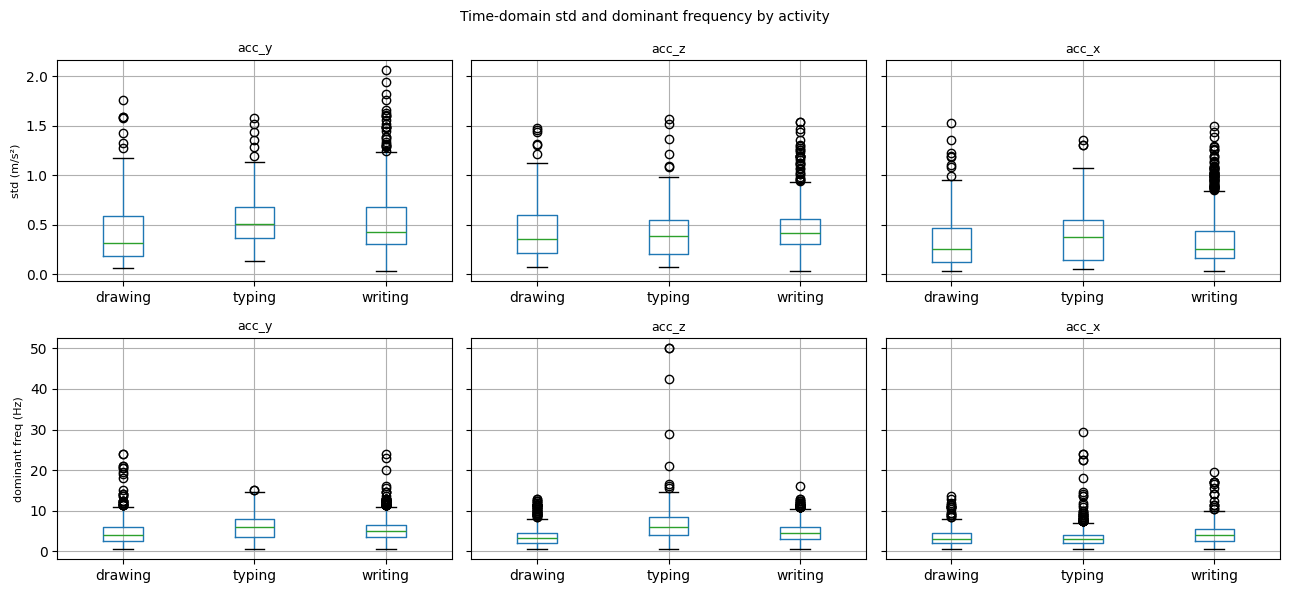

label                          drawing  typing  writing
WatchAccelerometer_y_std         0.411   0.534    0.503
WatchAccelerometer_y_max_freq    4.879   5.823    5.347
WatchAccelerometer_y_pse         2.722   3.509    3.102
WatchAccelerometer_z_std         0.433   0.388    0.449
WatchAccelerometer_z_max_freq    3.827   6.615    4.739
WatchAccelerometer_z_pse         2.828   3.645    3.169
WatchAccelerometer_x_std         0.324   0.372    0.328
WatchAccelerometer_x_max_freq    3.533   3.311    4.087
WatchAccelerometer_x_pse         2.783   3.092    2.926


In [27]:
acc_cols = [c for c in motion_cols if 'Accelerometer' in c]

fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharey='row')

for i, col in enumerate(acc_cols):
    for ax, feat, ylabel in zip(
        [axes[0, i], axes[1, i]],
        [f'{col}_std', f'{col}_max_freq'],
        ['std (m/s²)', 'dominant freq (Hz)'],
    ):
        features.boxplot(column=feat, by='label', ax=ax)
        ax.set_title(col.replace('WatchAccelerometer_', 'acc_'), fontsize=9)
        ax.set_xlabel('')
        if i == 0:
            ax.set_ylabel(ylabel, fontsize=8)

plt.suptitle('Time-domain std and dominant frequency by activity', fontsize=10)
plt.tight_layout()
plt.savefig('figures/feature_analysis.png', dpi=150)
plt.show()

# Per-label mean table for the report
key_cols = [f'{c}{s}' for c in acc_cols for s in ['_std', '_max_freq', '_pse']]
print(features.groupby('label')[key_cols].mean().round(3).T)

# Deep Learning: CNN-LSTM
In this section, a deep learning approach is taken. A CNN-LSTM model, inspired by Oluwalade et al., is trained for the HAR task: determining the activity type label (drawing, typing, writing, or outside/misc).

## Data Preparation
The shape of the input data is inspected below.

In [28]:
print(df.shape)
print(df['label'].value_counts(dropna=False))

(345092, 12)
label
writing    152403
typing      90803
drawing     51203
None        50683
Name: count, dtype: int64


In [29]:
subj1_df = df[df['subject'] == 1]
print(subj1_df.describe())

                                time   subject  WatchGyroscope_y  \
count                         151027  151027.0     151027.000000   
mean   2026-06-06 18:42:56.009999360       1.0         -0.008544   
min       2026-06-06 18:30:20.880000       1.0         -0.805120   
25%    2026-06-06 18:36:38.444999936       1.0         -0.046426   
50%    2026-06-06 18:42:56.009999872       1.0         -0.006109   
75%    2026-06-06 18:49:13.575000064       1.0          0.032987   
max       2026-06-06 18:55:31.140000       1.0          0.788016   
std                              NaN       0.0          0.142802   

       WatchGyroscope_z  WatchGyroscope_x  WatchAccelerometer_y  \
count     151027.000000     151027.000000         151027.000000   
mean           0.005043         -0.002259             -0.095702   
min           -0.900415         -1.806939             -2.916138   
25%           -0.025656         -0.059865             -0.287304   
50%            0.003665          0.000000           

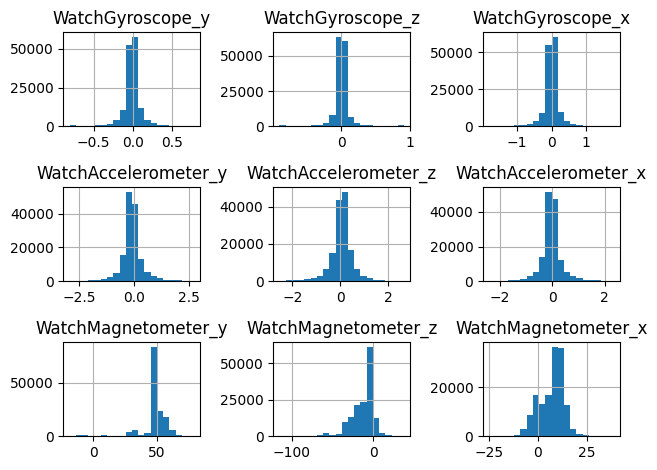

In [30]:
subj1_df[motion_cols].hist(bins=20)
plt.tight_layout()
plt.show()

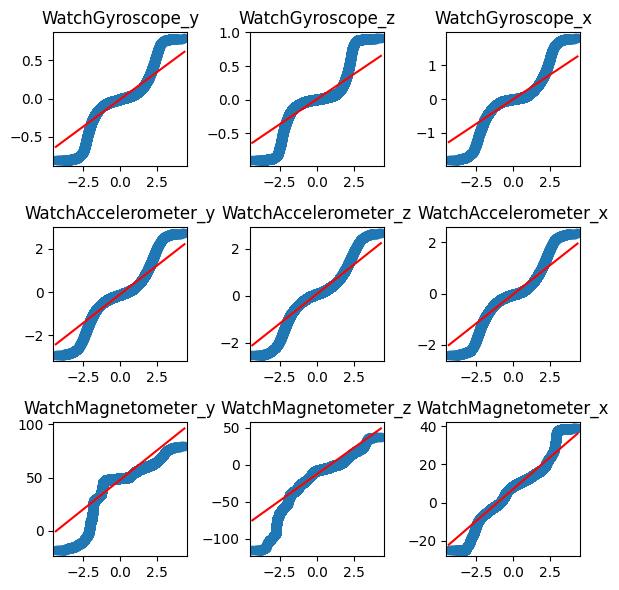

In [31]:
from statsmodels.graphics.gofplots import qqplot
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(6,6))
ax = ax.flatten()
for i, col in enumerate(motion_cols):
    s = subj1_df[col]
    qqplot(s, line='s', ax=ax[i])
    ax[i].set_title(col)
    ax[i].set_xlabel("")
    ax[i].set_ylabel("")
plt.tight_layout()
plt.show()

In [32]:
for col in motion_cols:
    s = subj1_df[col]
    stat, p = stats.normaltest(s)
    print(f'Statistic={stat:.3f}, p={p:e}')

Statistic=29460.896, p=0.000000e+00
Statistic=37904.750, p=0.000000e+00
Statistic=29199.310, p=0.000000e+00
Statistic=21214.812, p=0.000000e+00
Statistic=19110.302, p=0.000000e+00
Statistic=19899.875, p=0.000000e+00
Statistic=96076.179, p=0.000000e+00
Statistic=51912.650, p=0.000000e+00
Statistic=9036.954, p=0.000000e+00


Each D'Agostino's $K^2$ test result gives an extremely small p-value of approximately zero, much smaller than the significance level $\alpha=0.05$. Therefore, for each data series, the null hypothesis $H_0$ that the sample is Gaussian, is rejected. Thus, it is unlikely that the data of any of the motion columns are Gaussian.

## Data Normalization

As the data distributions are unlikely to be normal, each series of the training data is normalized with sci-kitlearn's `MinMaxScaler`. To avoid data leakage, each scaler that was fitted on the training data (i.e., subject 1) is used to normalize the test data (i.e., subject 2) and validation data (i.e., subject 3(=1b)) of the corresponding sensor-axis combination.

In [33]:
# Subject 1: Training set
scalers = dict()
normalized_df = df.copy()
print("Ranges pre-normalization:")
for col in motion_cols:
    s = normalized_df[normalized_df['subject'] == 1][col]
    vals = s.values
    reshaped_vals = vals.reshape(len(vals), 1)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaler.fit(reshaped_vals)
    print(f'{col} - Min: {scaler.data_min_}, Max: {scaler.data_max_}')
    normalized = scaler.transform(reshaped_vals)
    norm_reshaped = normalized.reshape(len(vals))
    normalized_df.loc[normalized_df['subject'] == 1, col] = norm_reshaped
    scalers[col] = scaler

print("\nTrain (subj1) -  Post-normalization:")
print(normalized_df[normalized_df['subject'] == 1].describe())

# Subject 2: Test set
for col in motion_cols:
    s = normalized_df[normalized_df['subject'] == 2][col]
    vals = s.values
    reshaped_vals = vals.reshape(len(vals), 1)
    scaler = scalers[col]

    normalized = scaler.transform(reshaped_vals)
    norm_reshaped = normalized.reshape(len(vals))
    normalized_df.loc[normalized_df['subject'] == 2, col] = norm_reshaped

print("\nTest (subj2) -  Post-normalization:")
print(normalized_df[normalized_df['subject'] == 2].describe())

# Subject 3 (=1b): Validation set
for col in motion_cols:
    s = normalized_df[normalized_df['subject'] == 3][col]
    vals = s.values
    reshaped_vals = vals.reshape(len(vals), 1)
    scaler = scalers[col]

    normalized = scaler.transform(reshaped_vals)
    norm_reshaped = normalized.reshape(len(vals))
    normalized_df.loc[normalized_df['subject'] == 3, col] = norm_reshaped

print("\nValidation (subj3=1b) -  Post-normalization:")
print(normalized_df[normalized_df['subject'] == 3].describe())

Ranges pre-normalization:
WatchGyroscope_y - Min: [-0.80512041], Max: [0.78801614]
WatchGyroscope_z - Min: [-0.90041536], Max: [0.91141093]
WatchGyroscope_x - Min: [-1.80693936], Max: [1.80083072]
WatchAccelerometer_y - Min: [-2.9161377], Max: [2.71981311]
WatchAccelerometer_z - Min: [-2.53785372], Max: [2.65995812]
WatchAccelerometer_x - Min: [-2.39899015], Max: [2.34631777]
WatchMagnetometer_y - Min: [-18.47999954], Max: [79.31999969]
WatchMagnetometer_z - Min: [-115.37999725], Max: [37.61999893]
WatchMagnetometer_x - Min: [-24.89999962], Max: [38.81999969]

Train (subj1) -  Post-normalization:
                                time   subject  WatchGyroscope_y  \
count                         151027  151027.0     151027.000000   
mean   2026-06-06 18:42:56.009999360       1.0          0.500005   
min       2026-06-06 18:30:20.880000       1.0          0.000000   
25%    2026-06-06 18:36:38.444999936       1.0          0.476227   
50%    2026-06-06 18:42:56.009999872       1.0          

Some of the normalized ranges of the sensor data in the test set (subject 2) and validation set (subject3(=1b)) exceed the normalized range of the training data ($[0, 1]$). E.g., in the test data, the z-axis of the Gyroscope sensor has a range of ca. $[-0.4, 1.4]$ post-normalization, indicating that the pre-normalization range of this data is wider than the pre-normalization range of the corresponding training data.

In [34]:
def window_label_split(df, motion_cols, window, step):
    rows = []
    train_rows = []
    test_rows = []
    val_rows = []
    
    for subj in [1, 2, 3]:
        subj_df = df[df['subject'] == subj].reset_index(drop=True)
        vals   = subj_df[motion_cols].values
        labels = subj_df['label'].values
        times  = subj_df['time'].values
        n      = len(subj_df)

        for t in range(window - 1, n, step):
            label = labels[t]
            if label is None:
                label = 'OUTSIDE'
            row = {'time': times[t], 'subject': subj, 'label': label}
            rows.append(row)

            # 200 instances in a time window of 2 sec, with 9 sensors,
            # gives a matrix of shape (200, 9) for each row (i.e., window)
            win = vals[t - window + 1 : t + 1]

            if subj == 1:  # Subject 1: Training set
                train_rows.append(win)
            elif subj == 2:  # Subject 2: Test set
                test_rows.append(win)
            elif subj == 3:  # Subject 3(=1b): Validation set
                val_rows.append(win)
                
    X_train = np.asarray(train_rows)
    X_test = np.asarray(test_rows)
    X_val = np.asarray(val_rows)
    windowed_df = pd.DataFrame(rows).reset_index(drop=True)

    return windowed_df, X_train, X_test, X_val

WINDOW  = 200                          
OVERLAP = 0.5                          
STEP    = int(WINDOW * (1 - OVERLAP))

windowed_df, X_train, X_test, X_val = window_label_split(normalized_df, motion_cols, WINDOW, STEP)

In [35]:
# Encode the string labels to integers for all subjects
le = LabelEncoder()
label_series = windowed_df['label']
le.fit(label_series)
label_ints = le.transform(label_series)
windowed_df['label_int'] = label_ints

print(windowed_df['label'].value_counts())
print(windowed_df['label_int'].value_counts())
print(windowed_df.shape)
print(windowed_df.head())

label
writing    1524
typing      908
drawing     512
OUTSIDE     503
Name: count, dtype: int64
label_int
3    1524
2     908
1     512
0     503
Name: count, dtype: int64
(3447, 4)
                     time  subject    label  label_int
0 2026-06-06 18:30:22.870        1  OUTSIDE          0
1 2026-06-06 18:30:23.870        1  OUTSIDE          0
2 2026-06-06 18:30:24.870        1  OUTSIDE          0
3 2026-06-06 18:30:25.870        1  OUTSIDE          0
4 2026-06-06 18:30:26.870        1  OUTSIDE          0


In [36]:
# Split the dataFrame into train (subj1), test (subj2) 
# and validation (subj3(=1b))
train_df = windowed_df[windowed_df['subject'] == 1]
test_df = windowed_df[windowed_df['subject'] == 2]
val_df = windowed_df[windowed_df['subject'] == 3]

# Convert integer classes to one-hot vectors
train_label_ints = train_df['label_int']
test_label_ints = test_df['label_int']
val_label_ints = val_df['label_int']
train_y: np.ndarray = keras.utils.to_categorical(
    train_label_ints, 
    num_classes=4
)
test_y: np.ndarray = keras.utils.to_categorical(
    test_label_ints, 
    num_classes=4
)
val_y: np.ndarray = keras.utils.to_categorical(
    val_label_ints, 
    num_classes=4
)

print(train_df['label'].value_counts())
print(train_df['label_int'].value_counts())
print(train_df.shape)
print(train_df.head())
print(train_y)
print(train_y.shape)

label
writing    735
typing     387
drawing    195
OUTSIDE    192
Name: count, dtype: int64
label_int
3    735
2    387
1    195
0    192
Name: count, dtype: int64
(1509, 4)
                     time  subject    label  label_int
0 2026-06-06 18:30:22.870        1  OUTSIDE          0
1 2026-06-06 18:30:23.870        1  OUTSIDE          0
2 2026-06-06 18:30:24.870        1  OUTSIDE          0
3 2026-06-06 18:30:25.870        1  OUTSIDE          0
4 2026-06-06 18:30:26.870        1  OUTSIDE          0
[[1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 ...
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]]
(1509, 4)


In [37]:
print(test_df['label'].value_counts())
print(test_df['label_int'].value_counts())
print(test_df.shape)
print(test_df.head())
print(test_y)
print(test_y.shape)

label
writing    627
typing     443
OUTSIDE    248
drawing    198
Name: count, dtype: int64
label_int
3    627
2    443
0    248
1    198
Name: count, dtype: int64
(1516, 4)
                        time  subject    label  label_int
1509 2026-06-06 19:07:42.600        2  OUTSIDE          0
1510 2026-06-06 19:07:43.600        2  OUTSIDE          0
1511 2026-06-06 19:07:44.600        2  OUTSIDE          0
1512 2026-06-06 19:07:45.600        2  OUTSIDE          0
1513 2026-06-06 19:07:46.600        2  OUTSIDE          0
[[1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 ...
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]]
(1516, 4)


In [38]:
print(val_df['label'].value_counts())
print(val_df['label_int'].value_counts())
print(val_df.shape)
print(val_df.head())
print(val_y)
print(val_y.shape)

label
writing    162
drawing    119
typing      78
OUTSIDE     63
Name: count, dtype: int64
label_int
3    162
1    119
2     78
0     63
Name: count, dtype: int64
(422, 4)
                        time  subject    label  label_int
3025 2026-06-18 06:30:24.550        3  OUTSIDE          0
3026 2026-06-18 06:30:25.550        3  OUTSIDE          0
3027 2026-06-18 06:30:26.550        3  OUTSIDE          0
3028 2026-06-18 06:30:27.550        3  OUTSIDE          0
3029 2026-06-18 06:30:28.550        3  OUTSIDE          0
[[1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 ...
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]]
(422, 4)


There are 1509 windows in the training set, 422 windows in the validation set, and 1516 windows in the test set. I.e., the training\:validation\:test split is approximately 44\:12\:44.

In [69]:
sum_windows = 1509+422+1516
print(f"{100*1509/sum_windows:.0f}")
print(f"{100*422/sum_windows:.0f}")
print(f"{100*1516/sum_windows:.0f}")

44
12
44


In [39]:
print(X_train.shape)
print(train_y.shape)

(1509, 200, 9)
(1509, 4)


## Hyperparameter optimization

The Adam learning rate, number of LSTM units, number of CNN filters, and CNN kernel size are tuned. With three values per hyperparameter, the total number of configurations in the search space equals $3^4=81$.

In [40]:
def build_model(hp):
    model = Sequential()
    model.add(Conv1D(
        filters=hp.Int('filters', min_value=32, max_value=128, step=2, sampling='log'),
        kernel_size=hp.Int('kernel_size', min_value=3, max_value=5, step=1),
        activation='relu'
    ))
    model.add(Dropout(0.4))
    model.add(LSTM(hp.Int('LSTM_units', min_value=64, max_value=256, step=2, sampling='log')))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(
        4,  # n_outputs: 4 classes
        activation='softmax'
    ))
    learning_rate=hp.Float("lr", min_value=1e-4, max_value=1e-2, step=10, sampling="log")
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy', 
        metrics=[F1Score(average='macro', name='macro_f1')]
    )
    return model

build_model(keras_tuner.HyperParameters())

<Sequential name=sequential, built=False>

In [41]:
tuner = keras_tuner.RandomSearch(
    hypermodel=build_model,
    objective=keras_tuner.Objective('val_macro_f1', direction='max'),
    max_trials=27,
    executions_per_trial=2,
    overwrite=False,
    directory='search',
    project_name='lr_cnn_lstm',
)

tuner.search_space_summary()

Search space summary
Default search space size: 4
filters (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 2, 'sampling': 'log'}
kernel_size (Int)
{'default': None, 'conditions': [], 'min_value': 3, 'max_value': 5, 'step': 1, 'sampling': 'linear'}
LSTM_units (Int)
{'default': None, 'conditions': [], 'min_value': 64, 'max_value': 256, 'step': 2, 'sampling': 'log'}
lr (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': 10, 'sampling': 'log'}


In [42]:
print("Search starting...")
tuner.search(X_train, train_y, epochs=2, validation_data=(X_val, val_y))
print("Search finished!")

Trial 27 Complete [00h 02m 01s]
val_macro_f1: 0.23531847447156906

Best val_macro_f1 So Far: 0.431353822350502
Total elapsed time: 01h 05m 19s
Search finished!


### Tuning search results

In [51]:
tuner.results_summary()

Results summary
Results in search\lr_cnn_lstm
Showing 10 best trials
Objective(name="val_macro_f1", direction="max")

Trial 15 summary
Hyperparameters:
filters: 128
kernel_size: 3
LSTM_units: 64
lr: 0.001
Score: 0.431353822350502

Trial 16 summary
Hyperparameters:
filters: 32
kernel_size: 5
LSTM_units: 64
lr: 0.001
Score: 0.3335719555616379

Trial 02 summary
Hyperparameters:
filters: 32
kernel_size: 4
LSTM_units: 64
lr: 0.01
Score: 0.3289894312620163

Trial 22 summary
Hyperparameters:
filters: 128
kernel_size: 3
LSTM_units: 256
lr: 0.0001
Score: 0.3218541890382767

Trial 08 summary
Hyperparameters:
filters: 64
kernel_size: 3
LSTM_units: 64
lr: 0.001
Score: 0.2994432672858238

Trial 14 summary
Hyperparameters:
filters: 32
kernel_size: 4
LSTM_units: 128
lr: 0.001
Score: 0.273300938308239

Trial 09 summary
Hyperparameters:
filters: 64
kernel_size: 4
LSTM_units: 128
lr: 0.001
Score: 0.27048446983098984

Trial 18 summary
Hyperparameters:
filters: 128
kernel_size: 3
LSTM_units: 128
lr: 0.001

In [46]:
models = tuner.get_best_models(num_models=2)
best_model = models[0]
best_model.summary()

C:\Users\kevyn\anaconda3\envs\group8_310\lib\site-packages\keras\src\saving\saving_lib.py:794: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 28 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (32, 198, 128)              │           3,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (32, 198, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (32, 64)                    │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (32, 100)                   │           6,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (32, 64)                    │           6,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (32, 64)                    │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (32, 32)                    │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (32, 4)                     │             132 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 68,168 (266.28 KB)

 Trainable params: 68,168 (266.28 KB)

 Non-trainable params: 0 (0.00 B)

## Model training and testing

In [64]:
def evaluate_model(best_hps, X_train, train_y, X_test, test_y, X_val, val_y, r: int):
    # Early stopping: min. val loss with patience
    # Only save the model with the best Macro F1
    batch_size = 32
    model_filename = f"models/repeat_{r}_best_model.keras"
    es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=20)
    mc = ModelCheckpoint(
        model_filename, 
        monitor='val_macro_f1', 
        mode='max',
        save_best_only=True,
        verbose=1
    )
    model = build_model(best_hps[0])
    model.fit(
        X_train, 
        train_y, 
        validation_data=(X_val, val_y),
        epochs=1000,
        batch_size=batch_size,
        verbose=True,
        callbacks=[es, mc]
    )
    # Collect the predictions
    raw_pred_probabilities = model.predict(
        X_test, 
        batch_size=batch_size, 
        verbose=True
    )
    test_y_pred = np.argmax(raw_pred_probabilities, axis=1)
    test_y_true = np.argmax(test_y, axis=1)
    target_names = le.classes_
    scores = classification_report(
        test_y_true,
        test_y_pred,
        target_names=target_names,
        output_dict=True
    )
    return scores

def run_experiment(best_hps, X_train, train_y, X_test, test_y, X_val, val_y, repeats=10):
    start = perf_counter()
    score_rows = []
    for r in range(repeats):
        scores = evaluate_model(
            best_hps, X_train, train_y, X_test, test_y, X_val, val_y, r
        )
        score_rows.append(scores)
    end = perf_counter()
    print("Time elapsed:", datetime.timedelta(seconds=(end - start)))
    return score_rows

repeats = 3
best_hps = tuner.get_best_hyperparameters(1)  # best params from tuning search
score_rows = run_experiment(
    best_hps, X_train, train_y, X_test, test_y, X_val, val_y, repeats=repeats
)

Epoch 1/1000
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 543ms/step - loss: 1.2576 - macro_f1: 0.1829
Epoch 1: val_macro_f1 improved from None to 0.20823, saving model to models/repeat_0_best_model.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 31s 652ms/step - loss: 1.2045 - macro_f1: 0.1930 - val_loss: 1.4100 - val_macro_f1: 0.2082
Epoch 2/1000
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 534ms/step - loss: 1.1906 - macro_f1: 0.2825
Epoch 2: val_macro_f1 did not improve from 0.20823
48/48 ━━━━━━━━━━━━━━━━━━━━ 30s 637ms/step - loss: 1.2027 - macro_f1: 0.2696 - val_loss: 1.3445 - val_macro_f1: 0.1467
Epoch 3/1000
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - loss: 1.1842 - macro_f1: 0.2247
Epoch 3: val_macro_f1 did not improve from 0.20823
48/48 ━━━━━━━━━━━━━━━━━━━━ 30s 617ms/step - loss: 1.1458 - macro_f1: 0.2917 - val_loss: 1.5714 - val_macro_f1: 0.1389
Epoch 4/1000
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - loss: 1.1756 - macro_f1: 0.2669
Epoch 4: val_macro_f1 improved from 0.20823 to 0.30757, saving model to models/repeat_0_be

C:\Users\kevyn\anaconda3\envs\group8_310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kevyn\anaconda3\envs\group8_310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kevyn\anaconda3\envs\group8_310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

Epoch 1/1000
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - loss: 1.2697 - macro_f1: 0.1760
Epoch 1: val_macro_f1 improved from None to 0.37487, saving model to models/repeat_1_best_model.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 32s 672ms/step - loss: 1.2063 - macro_f1: 0.2136 - val_loss: 1.2731 - val_macro_f1: 0.3749
Epoch 2/1000
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 534ms/step - loss: 1.0663 - macro_f1: 0.3276
Epoch 2: val_macro_f1 improved from 0.37487 to 0.43627, saving model to models/repeat_1_best_model.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 31s 642ms/step - loss: 0.9637 - macro_f1: 0.3608 - val_loss: 1.0504 - val_macro_f1: 0.4363
Epoch 3/1000
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 526ms/step - loss: 0.7118 - macro_f1: 0.5189
Epoch 3: val_macro_f1 did not improve from 0.43627
48/48 ━━━━━━━━━━━━━━━━━━━━ 30s 635ms/step - loss: 0.7434 - macro_f1: 0.5119 - val_loss: 1.2202 - val_macro_f1: 0.3760
Epoch 4/1000
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 538ms/step - loss: 0.9849 - macro_f1: 0.3871
Epoch 4: val_macro_f1 did not improv

C:\Users\kevyn\anaconda3\envs\group8_310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kevyn\anaconda3\envs\group8_310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kevyn\anaconda3\envs\group8_310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

Epoch 1/1000
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 533ms/step - loss: 1.2746 - macro_f1: 0.2055
Epoch 1: val_macro_f1 improved from None to 0.37911, saving model to models/repeat_2_best_model.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 31s 639ms/step - loss: 1.1990 - macro_f1: 0.2392 - val_loss: 1.2171 - val_macro_f1: 0.3791
Epoch 2/1000
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 528ms/step - loss: 1.1242 - macro_f1: 0.2827
Epoch 2: val_macro_f1 did not improve from 0.37911
48/48 ━━━━━━━━━━━━━━━━━━━━ 31s 639ms/step - loss: 1.1437 - macro_f1: 0.2823 - val_loss: 1.1531 - val_macro_f1: 0.3696
Epoch 3/1000
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 518ms/step - loss: 1.1609 - macro_f1: 0.3195
Epoch 3: val_macro_f1 improved from 0.37911 to 0.41199, saving model to models/repeat_2_best_model.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 30s 623ms/step - loss: 1.0341 - macro_f1: 0.3557 - val_loss: 1.0242 - val_macro_f1: 0.4120
Epoch 4/1000
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - loss: 0.8768 - macro_f1: 0.4594
Epoch 4: val_macro_f1 improved from 

C:\Users\kevyn\anaconda3\envs\group8_310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kevyn\anaconda3\envs\group8_310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kevyn\anaconda3\envs\group8_310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

## Evaluation results

In [73]:
macro_f1_scores = []
precision_scores = {}
recall_scores = {}
f1_scores = {}
class_cols = le.classes_

for col in class_cols:
    precision_scores[col] = []
    recall_scores[col] = []
    f1_scores[col] = []

for i in range(repeats):
    scores = score_rows[i]
    macro_f1_score = scores['macro avg']['f1-score']
    macro_f1_scores.append(macro_f1_score)
    scores_df = pd.DataFrame(scores)

    for col in class_cols:
        s = scores_df[col]
        precision_scores[col].append(s['precision'])
        recall_scores[col].append(s['recall'])
        f1_scores[col].append(s['f1-score'])

score_dicts = [precision_scores, recall_scores, f1_scores]
macro_f1_series = pd.Series(macro_f1_scores)
precision_df = pd.DataFrame(precision_scores)
recall_df = pd.DataFrame(recall_scores)
f1_scores_df = pd.DataFrame(f1_scores)
merged_scores_df = pd.DataFrame()
merged_scores_df['precision_mean'] = precision_df.mean()
merged_scores_df['precision_stdev'] = precision_df.std()
merged_scores_df['recall_mean'] = recall_df.mean()
merged_scores_df['recall_stdev'] = recall_df.std()
merged_scores_df['f1-scores_mean'] = f1_scores_df.mean()
merged_scores_df['f1-scores_stdev'] = f1_scores_df.std()

### Macro-averaged F1 score

In [82]:
print("Macro F1 per run:")
print(macro_f1_series, "\n")
print("Macro F1 Mean:", macro_f1_series.mean())
print("Macro F1 Stdev:", macro_f1_series.std(), "\n")

Macro F1 per run:
0    0.182105
1    0.211140
2    0.233562
dtype: float64 

Macro F1 Mean: 0.20893571000985509
Macro F1 Stdev: 0.025799353102153186 



### Precision scores

In [83]:
print("Precision per run (by class):")
print(precision_df, "\n")
print("Precision Mean (by class):")
print(merged_scores_df['precision_mean'], "\n")
print("Precision Stdev (by class):")
print(merged_scores_df['precision_stdev'], "\n")

Precision per run (by class):
    OUTSIDE  drawing    typing   writing
0  0.161983      0.0  0.021739  0.776923
1  0.149573      0.0  0.012658  0.574150
2  0.190476      0.0  0.015152  0.619614 

Precision Mean (by class):
OUTSIDE    0.167344
drawing    0.000000
typing     0.016516
writing    0.656895
Name: precision_mean, dtype: float64 

Precision Stdev (by class):
OUTSIDE    0.020972
drawing    0.000000
typing     0.004692
writing    0.106404
Name: precision_stdev, dtype: float64 



### Recall scores

In [81]:
print("Recall per run (by class):")
print(recall_df, "\n")
print("Recall Mean (by class):")
print(recall_df.mean(), "\n")
print("Recall Stdev (by class):")
print(recall_df.std(), "\n")

Recall per run (by class):
    OUTSIDE  drawing    typing   writing
0  0.790323      0.0  0.002257  0.322169
1  0.423387      0.0  0.002257  0.673046
2  0.596774      0.0  0.002257  0.665072 

Recall Mean (by class):
OUTSIDE    0.603495
drawing    0.000000
typing     0.002257
writing    0.553429
dtype: float64 

Recall Stdev (by class):
OUTSIDE    0.183560
drawing    0.000000
typing     0.000000
writing    0.200317
dtype: float64 



### F1-scores

In [79]:
print("F1-scores per run (by class):")
print(f1_scores_df, "\n")
print("F1-scores Mean (by class):")
print(merged_scores_df['f1-scores_mean'], "\n")
print("F1-scores Stdev (by class):")
print(merged_scores_df['f1-scores_stdev'], "\n")

F1-scores per run (by class):
    OUTSIDE  drawing    typing   writing
0  0.268861      0.0  0.004090  0.455468
1  0.221053      0.0  0.003831  0.619677
2  0.288780      0.0  0.003929  0.641538 

F1-scores Mean (by class):
OUTSIDE    0.259565
drawing    0.000000
typing     0.003950
writing    0.572228
Name: f1-scores_mean, dtype: float64 

F1-scores Stdev (by class):
OUTSIDE    0.034808
drawing    0.000000
typing     0.000131
writing    0.101706
Name: f1-scores_stdev, dtype: float64 



### Merged scores

In [78]:
merged_scores_df

,precision_mean,precision_stdev,recall_mean,recall_stdev,f1-scores_mean,f1-scores_stdev
OUTSIDE,0.167344,0.020972,0.603495,0.183560,0.259565,0.034808
drawing,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
typing,0.016516,0.004692,0.002257,0.000000,0.003950,0.000131
writing,0.656895,0.106404,0.553429,0.200317,0.572228,0.101706
